In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# 랜덤 초기값 세팅
np.random.seed(42)
torch.manual_seed(42)


In [2]:
data = {
    'temperature': [10, 15, 22, 25, 28, 35, 38],
    'humidity':    [30, 40, 50, 55, 60, 70, 80],
    'y':           [ 0,  0,  1,  1,  1,  0,  0]
}
df = pd.DataFrame(data)
df

,temperature,humidity,y
0,10,30,0
1,15,40,0
2,22,50,1
3,25,55,1
4,28,60,1
5,35,70,0
6,38,80,0


In [3]:
# 원본 입력데이터를 넘파이 (n,2)배열로 바꿈
X_raw = df[['temperature', 'humidity']].to_numpy(dtype=np.float32)
X_raw

array([[10., 30.],
       [15., 40.],
       [22., 50.],
       [25., 55.],
       [28., 60.],
       [35., 70.],
       [38., 80.]], dtype=float32)

In [4]:
# 정답 컬럼 y
y = df['y'].to_numpy(dtype=np.float32).reshape(-1, 1)
y

array([[0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.]], dtype=float32)

In [5]:
# 입력값 정규화 하기위해 컬럼별 평균, 표준편차 구함. 차원 그대로 유지
X_mean = X_raw.mean(axis=0, keepdims=True)
X_std = X_raw.std(axis=0, keepdims=True)

print(f'X_mean={X_mean}, X_std={X_std}')

X_mean=[[24.714285 55.      ]], X_std=[[ 9.345959 15.811388]]


In [6]:
# 정규화
X_norm = (X_raw - X_mean) / X_std
X_norm

array([[-1.5744008 , -1.5811388 ],
       [-1.0394102 , -0.9486833 ],
       [-0.29042336, -0.31622776],
       [ 0.03057098,  0.        ],
       [ 0.35156533,  0.31622776],
       [ 1.1005522 ,  0.9486833 ],
       [ 1.4215466 ,  1.5811388 ]], dtype=float32)

In [7]:
# X_norm을 Tensor로 변환
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
X_tensor

tensor([[-1.5744, -1.5811],
        [-1.0394, -0.9487],
        [-0.2904, -0.3162],
        [ 0.0306,  0.0000],
        [ 0.3516,  0.3162],
        [ 1.1006,  0.9487],
        [ 1.4215,  1.5811]])

In [8]:
# 정답도 tensor로 변환
y_tensor = torch.tensor(y, dtype=torch.float32)
y_tensor

tensor([[0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.]])

In [9]:
# Linear 계층 만들기 전에 난수 고정
torch.manual_seed(42)
# 히든 레이어
# 입력 2개를 받아 히든뉴런 2개의 선형 값 출력
hidden_layer = torch.nn.Linear(2, 2)
# 출력층
# 히든 뉴런 2개의 출력을 받아 최종 출력 1개의 선형값 만듦
output_layer = torch.nn.Linear(2, 1)

hidden_layer, output_layer

(Linear(in_features=2, out_features=2, bias=True),
 Linear(in_features=2, out_features=1, bias=True))

In [10]:
def bce_cost_torch(y, z_output):
    epsilon = 1e-7
    # z_output  범위를 epsilon으로 살짝 잘라 log(0)막기
    z_output = torch.clamp(z_output, epsilon, 1 - epsilon)
    cost = -torch.mean(
        y * torch.log(z_output) + (1 - y) * torch.log(1 - z_output)
    )
    return cost

In [11]:
# 순전파 실행
# X_tensor에는 입력 2개(정규화된 온도, 습도)
H_hidden = hidden_layer(X_tensor)

# 선형값을 sigmoid에 통과시킴
z_hidden = torch.sigmoid(H_hidden)

# 최종 선형값 계산
H_output = output_layer(z_hidden)

# 최종 예측 확률
z_output = torch.sigmoid(H_output)

In [12]:
H_hidden, z_hidden, H_output, z_output

(tensor([[-1.9340, -0.6235],
         [-1.2736, -0.3014],
         [-0.4975, -0.0146],
         [-0.1384,  0.1376],
         [ 0.2207,  0.2899],
         [ 0.9968,  0.5766],
         [ 1.5416,  0.9342]], grad_fn=<AddmmBackward0>),
 tensor([[0.1263, 0.3490],
         [0.2186, 0.4252],
         [0.3781, 0.4963],
         [0.4655, 0.5344],
         [0.5550, 0.5720],
         [0.7304, 0.6403],
         [0.8237, 0.7179]], grad_fn=<SigmoidBackward0>),
 tensor([[0.7248],
         [0.7247],
         [0.6993],
         [0.6850],
         [0.6698],
         [0.6378],
         [0.6379]], grad_fn=<AddmmBackward0>),
 tensor([[0.6737],
         [0.6736],
         [0.6680],
         [0.6649],
         [0.6615],
         [0.6543],
         [0.6543]], grad_fn=<SigmoidBackward0>))

In [13]:
cost = bce_cost_torch(y_tensor, z_output)
H_hidden.shape, z_output.shape, cost.item()

(torch.Size([7, 2]), torch.Size([7, 1]), 0.7983762621879578)

In [14]:
learning_rate = 0.5
epochs = 3000
cost_history = []

In [15]:
training_log = []

# hidden_layer, output_layer의 파라미터를 합쳐서 넘기기
optimizer = torch.optim.SGD(
    list(hidden_layer.parameters()) + list(output_layer.parameters()), lr=learning_rate
)
for epoch in range(epochs):
    # gradient 초기화
    optimizer.zero_grad()

    # 순전파
    H_hidden = hidden_layer(X_tensor)
    z_hidden = torch.sigmoid(H_hidden)
    H_output = output_layer(z_hidden)
    z_output = torch.sigmoid(H_output)

    # cost 계산
    cost = bce_cost_torch(y_tensor, z_output)
    cost_history.append(cost.item())

    # gradient 계산
    cost.backward()

    # 대표 epoch 과정 기록
    if epoch % 500 == 0:
        training_log.append({
            'epoch': epoch,
            'cost': cost.item(),
            'hidden_w_00': hidden_layer.weight[0,0].item(),
            'hidden_b_0': hidden_layer.bias[0].item(),
            'output_w_00': output_layer.weight[0,0].item(),
            'output_b_0': output_layer.bias[0].item(),
            'hidden_w_00_grad': hidden_layer.weight.grad[0,0].item() if hidden_layer.weight.grad is not None else float('nan'),
            'hidden_b_0_grad': hidden_layer.bias.grad[0].item() if hidden_layer.bias.grad is not None else float('nan'),
            'output_w_00_grad': output_layer.weight.grad[0,0].item() if output_layer.weight.grad is not None else float('nan'),
            'output_b_0_grad': output_layer.bias.grad[0].item() if output_layer.bias.grad is not None else float('nan'),
        })
        print(f'epoch={epoch:4d}, cost={cost.item():.6f}')

    # 파라미터 업데이트
    optimizer.step()

epoch=   0, cost=0.798376
epoch= 500, cost=0.095704
epoch=1000, cost=0.029810
epoch=1500, cost=0.017091
epoch=2000, cost=0.011887
epoch=2500, cost=0.009083


In [16]:
training_log_df = pd.DataFrame(training_log)
training_log_df

,epoch,cost,hidden_w_00,hidden_b_0,output_w_00,output_b_0,hidden_w_00_grad,hidden_b_0_grad,output_w_00_grad,output_b_0_grad
0,0,0.798376,0.540610,-0.154930,-0.344258,0.623345,-0.001521,-0.008272,0.111398,0.235739
1,500,0.095704,2.858203,-3.742404,-6.046050,-2.426894,-0.004335,0.005304,0.015467,0.008551
2,1000,0.029810,3.440474,-4.471745,-8.297037,-3.634869,-0.001341,0.001706,0.005574,0.002917
3,1500,0.017091,3.689094,-4.788891,-9.362078,-4.188004,-0.000752,0.000961,0.003318,0.001712
4,2000,0.011887,3.843720,-4.986603,-10.057146,-4.545533,-0.000513,0.000656,0.002350,0.001205
5,2500,0.009083,3.954681,-5.128524,-10.572248,-4.809307,-0.000386,0.000493,0.001815,0.000928


In [17]:
# 학습후 cost 숫자 확인
cost_history[0], cost_history[-1], 'cost decreased:', cost_history[-1] < cost_history[0]

(0.7983762621879578, 0.007340637035667896, 'cost decreased:', True)

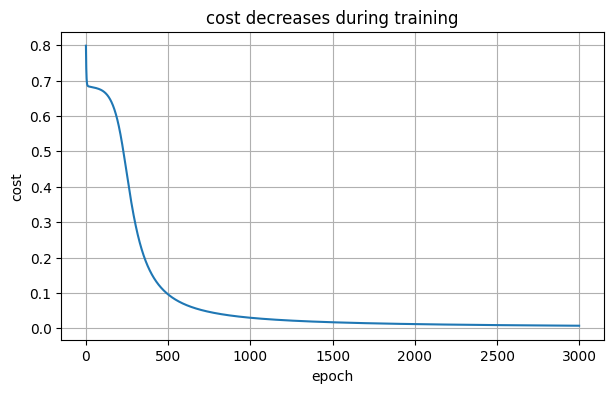

In [18]:
plt.figure(figsize=(7,4))
plt.plot(cost_history)
plt.xlabel('epoch')
plt.ylabel('cost')
plt.title('cost decreases during training')
plt.grid(True)

In [19]:
# 학습 끝난 파라미터로 최종 예측
with torch.no_grad():
    H_hidden = hidden_layer(X_tensor)
    z_hidden = torch.sigmoid(H_hidden)

    H_output = output_layer(z_hidden)
    z_output = torch.sigmoid(H_output)

    pred = (z_output >= 0.5).float()
    accuracy = (pred == y_tensor).float().mean()

result_df = df[['temperature', 'humidity', 'y']].copy()

# 계산추적 끊고 numpy배열로 바꾸기
z_output_np = z_output.detach().numpy()
# (n,1)배열에서 1차원 배열로 바꾸기
z_output_1d = z_output_np.reshape(-1)
# 소수점 4자리 반올림
result_df['z_output'] = z_output_1d.round(4)

pred_np = pred.detach().numpy()
pred_1d = pred_np.reshape(-1)
result_df['pred'] = pred_1d.astype(int)
print('accuracy:', accuracy.item())
result_df

accuracy: 1.0


,temperature,humidity,y,z_output,pred
0,10,30,0,0.0066,0
1,15,40,0,0.0102,0
2,22,50,1,0.9907,1
3,25,55,1,0.9953,1
4,28,60,1,0.9911,1
5,35,70,0,0.0072,0
6,38,80,0,0.0042,0
